In [40]:
import pandas as pd
import numpy as np



In [41]:
df = pd.read_csv("raw_books.csv")
print(df.head())



                                               title         category   price  \
0  The Boys in the Boat: Nine Americans and Their...          Default  £22.60   
1  Mesaerion: The Best Science Fiction Stories 18...  Science Fiction  £37.59   
2  The Dirty Little Secrets of Getting Your Dream...         Business  £33.34   
3                                    The Requiem Red      Young Adult  £22.65   
4                       Libertarianism for Beginners         Politics  £51.33   

  rating                                       availability  \
0   Four  In stock (19 available) In stock In stock In s...   
1    One  In stock (19 available) In stock In stock In s...   
2   Four  In stock (19 available) In stock In stock In s...   
3    One  In stock (19 available) In stock In stock In s...   
4    Two  In stock (19 available) In stock In stock In s...   

                                 product_description               UPC  \
0  For readers of Laura Hillenbrand's Seabiscuit ...  e10e1e

In [42]:
# Total number of scraped # Check for missing values
print("Total Records:", len(df))
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate UPC Values:")
print(df["UPC"].duplicated().sum())



Total Records: 100

Missing Values:
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
UPC                    0
number_of_reviews      0
product_url            0
dtype: int64

Duplicate UPC Values:
0


In [43]:
# removing extra spaces
df["title"] = df["title"].str.strip()
df["category"] = df["category"].str.strip()
df["availability"] = df["availability"].str.strip()
df["product_description"] = df["product_description"].fillna("").str.strip()



In [44]:
# Removing duplicates 
df = df.drop_duplicates(subset="UPC")
print("\nTotal Records after removing duplicates:", len(df))




Total Records after removing duplicates: 100


In [45]:
print(df["price"].dtype)
print(df["price"].head())

object
0    £22.60
1    £37.59
2    £33.34
3    £22.65
4    £51.33
Name: price, dtype: object


In [46]:

# convert price from string to float, e.g. "£53.74" -> 53.74
df["price"] = df["price"].str.replace("£", "").astype(float)
df["rating"] = df["rating"].str.strip()

In [47]:
# Converting ratings from text to numeric
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)



In [48]:
df["stock_count"] = df["availability"].str.extract(r"(\d+)")
df["stock_count"] = df["stock_count"].fillna(0).astype(int)

df["description_word_count"] = (
    df["product_description"]
    .apply(lambda description: len(str(description).split()))
)

# Categorize books by price
df["price_band"] = pd.cut(
    df["price"],
    bins=[0, 20, 40, 100],
    labels=["Low", "Medium", "High"]
)



In [49]:
# Calculate affordability score (rating per unit price)
df["affordability_score"] = (
    df["rating"] / df["price"]
).round(2)



In [50]:
# Recommend books with rating >= 4 and price < 35
df["recommended"] = np.where(
    (df["rating"] >= 4) & (df["price"] < 35),
    "Yes",
    "No"
)



In [51]:
# Display transformed columns
print("\nPreview of cleaned data:")
print(df[[
    "title",
    "price",
    "rating",
    "stock_count",
    "price_band",
    "affordability_score",
    "recommended"
]].head())

# Save cleaned dataset
df.to_csv("raw_books_main.csv", index=False)

print("\nCleaned dataset saved successfully as 'raw_books_main.csv'.")



Preview of cleaned data:
                                               title  price  rating  \
0  The Boys in the Boat: Nine Americans and Their...  22.60       4   
1  Mesaerion: The Best Science Fiction Stories 18...  37.59       1   
2  The Dirty Little Secrets of Getting Your Dream...  33.34       4   
3                                    The Requiem Red  22.65       1   
4                       Libertarianism for Beginners  51.33       2   

   stock_count price_band  affordability_score recommended  
0           19     Medium                 0.18         Yes  
1           19     Medium                 0.03          No  
2           19     Medium                 0.12         Yes  
3           19     Medium                 0.04          No  
4           19       High                 0.04          No  

Cleaned dataset saved successfully as 'raw_books_main.csv'.


In [52]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud



In [54]:
# Apply plot style
sns.set_theme(style="whitegrid")

# Read the cleaned dataset (produced by cleaning.py)
books = pd.read_csv("raw_books_main.csv")

print(books.head())



                                               title         category  price  \
0  The Boys in the Boat: Nine Americans and Their...          Default  22.60   
1  Mesaerion: The Best Science Fiction Stories 18...  Science Fiction  37.59   
2  The Dirty Little Secrets of Getting Your Dream...         Business  33.34   
3                                    The Requiem Red      Young Adult  22.65   
4                       Libertarianism for Beginners         Politics  51.33   

   rating                                       availability  \
0       4  In stock (19 available) In stock In stock In s...   
1       1  In stock (19 available) In stock In stock In s...   
2       4  In stock (19 available) In stock In stock In s...   
3       1  In stock (19 available) In stock In stock In s...   
4       2  In stock (19 available) In stock In stock In s...   

                                 product_description               UPC  \
0  For readers of Laura Hillenbrand's Seabiscuit ...  e10e1e

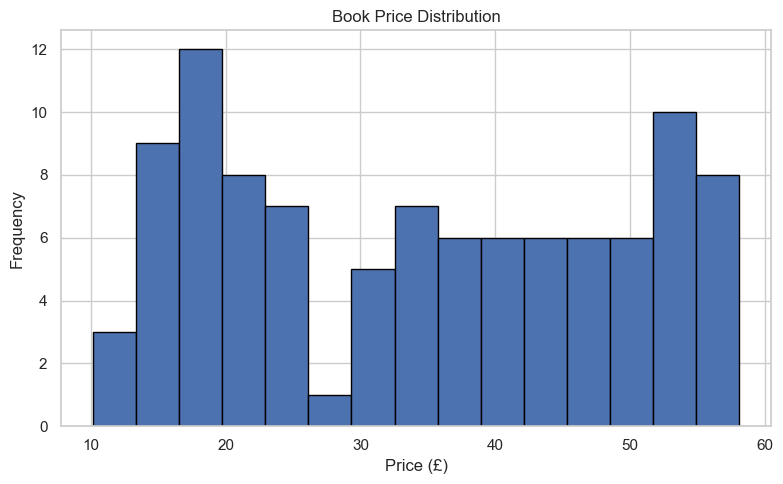

In [38]:

# Price Distribution

plt.figure(figsize=(8, 5))
plt.hist(books["price"], bins=15, edgecolor="black")
plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plot_price_distribution.png", dpi=150)
plt.show()



**1. Prices are broadly spread with no single cluster.**
price ranges from £10.16 to £58.11, with a mean of £34.56 and a median of £34.78 — close enough that the distribution isn't heavily skewed. Books split into 26 "Low" (<£20), 34 "Medium" (£20–£40), and 40 "High" (£40+) priced items, so the catalogue leans toward the pricier end.

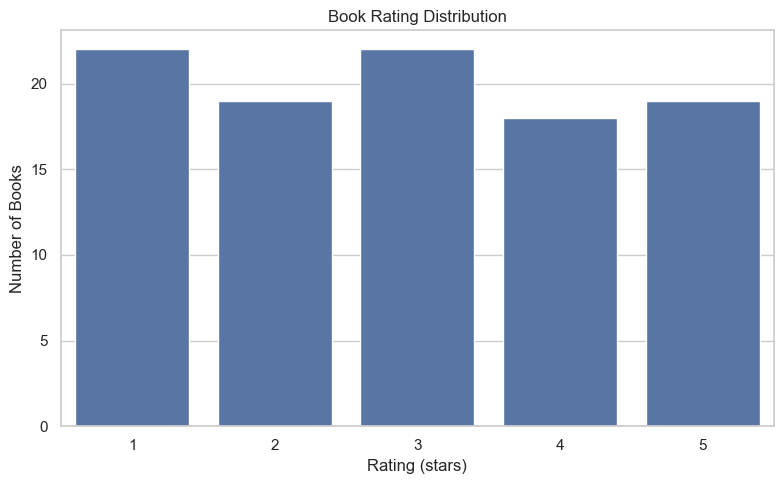

In [55]:
# Rating Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="rating", data=books, order=sorted(books["rating"].unique()))
plt.title("Book Rating Distribution")
plt.xlabel("Rating (stars)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("plot_rating_distribution.png", dpi=150)
plt.show()



**2. Price and rating show essentially no relationship.**
The correlation between `price` and `rating` is **-0.12** — negligible. The price-vs-rating scatter plot backs this up: expensive books are just as likely to have a 1-star rating as a 5-star one, and cheap books show the same spread. On this dataset, price is not a useful proxy for quality — it likely reflects book length/format rather than reader reception, since these are placeholder ratings rather than real reviews.
**3. Ratings are fairly evenly distributed, with a slight dip at 4 stars.**
The rating breakdown is 1★: 22, 2★: 19, 3★: 22, 4★: 18, 5★: 19 books, giving an average of 2.93. There's no strong skew toward high or low ratings — the catalogue doesn't lean "mostly great" or "mostly poor."


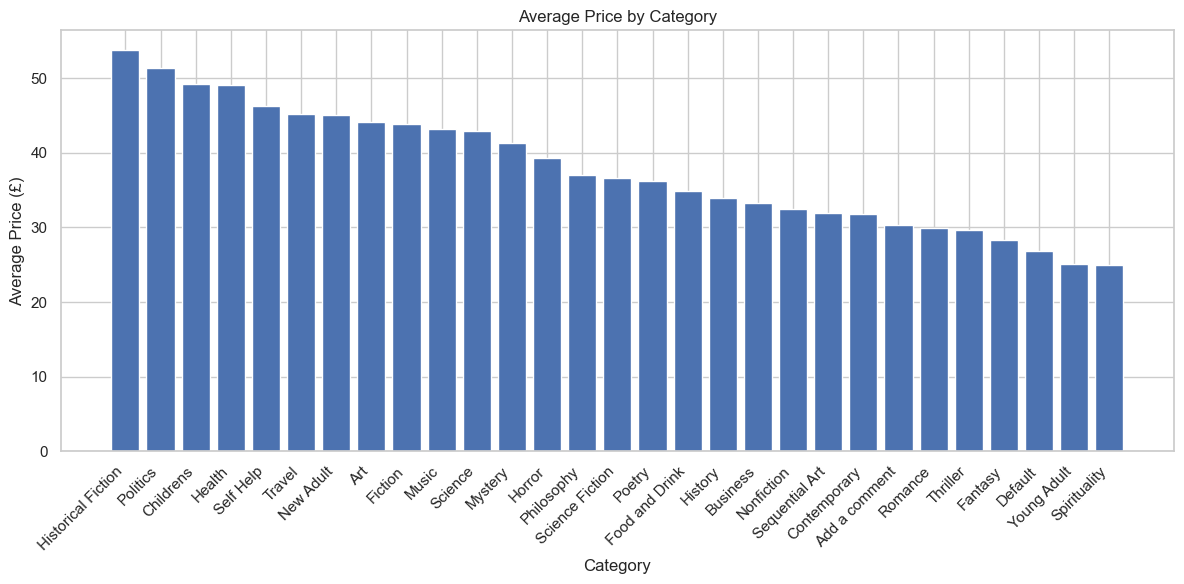

In [56]:
# Average Price in Each Category


category_prices = books.groupby("category")["price"].mean()
category_prices = category_prices.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(category_prices.index, category_prices.values)
plt.xticks(rotation=45, ha="right")
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.tight_layout()
plt.savefig("plot_avg_price_by_category.png", dpi=150)
plt.show()



**4. Sequential Art and Nonfiction dominate by volume, but aren't the priciest.**
Sequential Art (14 books) and Nonfiction (12 books) are the two most-represented categories, together making up over a quarter of the catalogue. Despite that volume, their average prices (£31.91 and £32.48) sit close to the dataset mean rather than at the extremes.

**5. Childrens and Fiction are the most expensive categories on average.**
Among categories with at least two books, **Childrens** (avg £49.22), **Fiction** (avg £43.87), and **Music** (avg £43.20) top the price list — considerably above the £34.56 overall average. Interestingly, Childrens also has the lowest average rating among these (1.67), reinforcing point 2: higher price categories aren't rated any better.

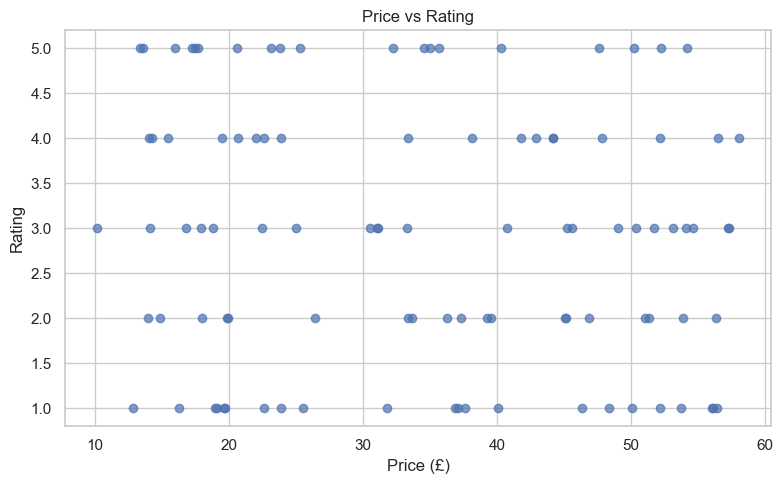

In [57]:

# Price and Rating Comparison


plt.figure(figsize=(8, 5))
plt.scatter(books["price"], books["rating"], alpha=0.7)
plt.title("Price vs Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("plot_price_vs_rating.png", dpi=150)
plt.show()



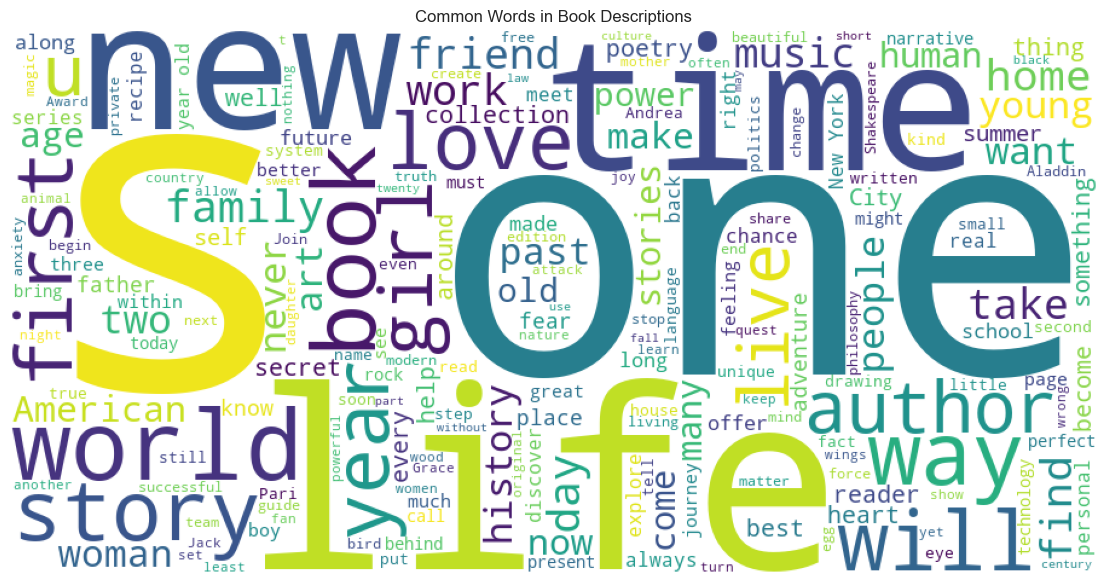

In [58]:

# Word Cloud


all_descriptions = " ".join(books["product_description"].fillna(""))

cloud = WordCloud(width=900, height=450, background_color="white")
cloud.generate(all_descriptions)

plt.figure(figsize=(12, 6))
plt.imshow(cloud)
plt.axis("off")
plt.title("Common Words in Book Descriptions")
plt.tight_layout()
plt.savefig("plot_wordcloud.png", dpi=150)
plt.show()



In [59]:
# Dataset Summary

print("\nSummary Statistics\n")
print(books.describe(include="all"))




Summary Statistics

                                                    title        category  \
count                                                 100             100   
unique                                                100              29   
top     The Boys in the Boat: Nine Americans and Their...  Sequential Art   
freq                                                    1              14   
mean                                                  NaN             NaN   
std                                                   NaN             NaN   
min                                                   NaN             NaN   
25%                                                   NaN             NaN   
50%                                                   NaN             NaN   
75%                                                   NaN             NaN   
max                                                   NaN             NaN   

             price      rating  \
count   100.000000  

In [60]:

# Highest Rated Books


best_books = books.sort_values(["rating", "price"], ascending=[False, True])

print("\nTop Rated Books\n")
print(best_books[["title", "category", "rating", "price"]].head(10))




Top Rated Books

                                                title        category  rating  \
98   Princess Between Worlds (Wide-Awake Princess #5)         Fantasy       5   
95  Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...  Sequential Art       5   
18                                     Sophie's World      Philosophy       5   
58                                             Thirst         Fiction       5   
13                                        Set Me Free     Young Adult       5   
22  The Four Agreements: A Practical Guide to Pers...    Spirituality       5   
73  The Inefficiency Assassin: Time Management Tac...         Default       5   
50  #HigherSelfie: Wake Up Your Life. Free Your So...      Nonfiction       5   
25                                  The Elephant Tree        Thriller       5   
32                         Chase Me (Paris Nights #2)         Romance       5   

    price  
98  13.34  
95  13.61  
18  15.94  
58  17.27  
13  17.46  
22  17.66  
73  20

In [61]:
# Category Statistics


category_stats = books.groupby("category").agg(
    Average_Price=("price", "mean"),
    Average_Rating=("rating", "mean"),
    Total_Stock=("stock_count", "sum")
)

category_stats = category_stats.round(2)

print("\nCategory Summary\n")
print(category_stats)



Category Summary

                    Average_Price  Average_Rating  Total_Stock
category                                                      
Add a comment               30.34            2.60           80
Art                         44.18            4.00           18
Business                    33.34            4.00           19
Childrens                   49.22            1.67           53
Contemporary                31.77            1.00           16
Default                     26.85            3.00          163
Fantasy                     28.38            3.25           64
Fiction                     43.87            3.80           85
Food and Drink              34.89            2.20           83
Health                      49.05            3.00           16
Historical Fiction          53.74            1.00           20
History                     33.94            2.25           68
Horror                      39.25            2.00           16
Music                       43.20   








**6. A clear set of "best value" books stands out.**
Using `affordability_score` (rating ÷ price), the top picks are dominated by 5-star books under £18 — for example *Princess Jellyfish 2-in-1 Omnibus* (£13.61, 5★), *Princess Between Worlds* (£13.34, 5★), and *Sophie's World* (£15.94, 5★). 21 of the 100 books meet the `recommended` criteria (rating ≥ 4 and price < £35).

**7. Stock levels are stable and not tied to price or rating.**
`stock_count` ranges narrowly from 16 to 22 (mean 17.2, median 16) with no books out of stock. Total stock is highest in the high-volume categories (Sequential Art: 227 units, Nonfiction: 198 units) simply because they have more titles — there's no indication that popular or well-rated books are stocked differently from the rest.



## Limitations

- Single-source sample: only 100 of the site's ~1,000 books were scraped (5 of ~50 catalog pages).
- Ratings on books.toscrape.com are static placeholder data, not real reader feedback.
- The site has no customer review text, so the word cloud uses product descriptions instead, and
  `number_of_reviews` is always 0.
- `stock_count` reflects a single point-in-time snapshot at scrape time.